In [1]:
try:
    import xlearn
except:
    !pip install -q -U xlearn
    import xlearn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 57.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [2]:
!pip show gcc cmake
print()
!pip show xlearn

Name: cmake
Version: 3.31.10
Summary: CMake is an open-source, cross-platform family of tools designed to build, test and package software
Home-page: https://cmake.org
Author: 
Author-email: Jean-Christophe Fillion-Robin <jchris.fillionr@kitware.com>
License: Apache 2.0
Location: /usr/local/lib/python3.12/dist-packages
Requires: 
Required-by: 

Name: xlearn
Version: 0.40a1
Summary: xLearn Python Package
Home-page: https://github.com/aksnzhy/xlearn
Author: 
Author-email: 
License: Apache-2.0
Location: /usr/local/lib/python3.12/dist-packages
Requires: 
Required-by: 


In [3]:
# %reset -f

In [4]:
## -- System dependencies --
import sys, os, gc
import torch

## -- Device-Agnostic (GPU/CPU) --
def get_system_info():
    if torch.cuda.is_available():
        return f"GPU: {torch.cuda.get_device_name(0)}"
    else:
        return f"CPU: {os.cpu_count()}"

get_system_info()

'CPU: 4'

In [5]:
## -- Data Manipulation --
import numpy as np, pandas as pd, random

## -- Visualization --
from IPython.display import display, Image
import matplotlib.pyplot as plt
import seaborn as sns

## -- Functional Tools --
import shutil, itertools
from time import time, sleep
from tqdm import tqdm
# from tqdm.notebook import tqdm

# import tensorflow as tf

## -- Machine Learning --
from sklearn.utils.class_weight import compute_class_weight
from sklearn.calibration import CalibrationDisplay, CalibratedClassifierCV
from sklearn.model_selection import KFold, StratifiedKFold, train_test_split
from sklearn.preprocessing import StandardScaler, label_binarize #, TargetEncoder
from sklearn.metrics import roc_auc_score, log_loss, ConfusionMatrixDisplay, RocCurveDisplay

import warnings
warnings.simplefilter('ignore')
warnings.filterwarnings('ignore')

In [6]:
## -- Set Configuration --
# sklearn.set_config(transform_output="pandas")
# pd.options.mode.copy_on_write = True
pd.set_option("display.max_columns", 100)
sns.set_style("whitegrid")
# plt.style.use('ggplot')

# plt.rcParams['axes.prop_cycle'] = cycler(color=['red', 'green', 'blue'])
plt.rcParams.update({
    # "figure.facecolor": '#0f0f1a', # Outer panel (figure)
    # "axes.facecolor":   '#1a1a2e', # Inner panel (image)
    # "axes.edgecolor":   '#444466',
    # "axes.labelcolor":  '#e0e0ff',
    # "text.color":       'lightblue',
    # "xtick.color":      '#e0e0ff',
    # "ytick.color":      '#e0e0ff',
    # "grid.color":       '#2a2a4a',
    # "grid.alpha":       0.5,
    "font.family":      'monospace',
})

PALETTE = ['c', 'r', 'darkorange', '#3A86FF', 'y']
sns.set_palette(PALETTE)
cmap = sns.diverging_palette(0, 230, 90, 60, as_cmap=True)

## -- Set Global Seed --
CFG = {
    'FOLDS':   5,
    'SEED':    42,
    'GREEN':  '\033[32m',
    'YELLOW': '\033[33m',
    'RESET':  '\033[0m'
}

print(f"CLASSIC {CFG['GREEN']} GREEN {CFG['RESET']} {CFG['YELLOW']} YELLOW {CFG['RESET']}")

CLASSIC  GREEN   YELLOW 


In [7]:
train = pd.read_csv("/kaggle/input/competitions/playground-series-s6e9/train.csv")
test = pd.read_csv("/kaggle/input/competitions/playground-series-s6e9/test.csv")
orig = pd.read_csv("/kaggle/input/datasets/itzzomkar/ev-adoption-behavior-and-range-anxiety/EV_Adoption_and_Range_Anxiety_Dataset.csv")
submission = pd.read_csv('/kaggle/input/competitions/playground-series-s6e9/sample_submission.csv')

ID      = "id"
TARGET  = "Will_Buy_EV"
obj = train.select_dtypes(include=["object", "category"]).columns.tolist()

cat_cols = [c for c in obj if c not in [TARGET, ID]]
num_cols = [c for c in train.columns if c not in cat_cols+[TARGET, ID]]
base_cols = num_cols + cat_cols

train[TARGET] = train[TARGET].map({'Yes': 1, 'No': 0})
orig[TARGET]  = orig[TARGET].map({'Yes': 1, 'No': 0})

print("Train shape:", train.shape)
print("Test shape :", test.shape)
print("Orig shape :", orig.shape)

train

Train shape: (668665, 15)
Test shape : (286571, 14)
Orig shape : (10000, 15)


,id,Age,Annual_Income_USD,Daily_Commute_km,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level,Gender,City_Type,Current_Car_Type,Home_Charging_Possible,Subsidy_Available,Range_Anxiety_Level,Will_Buy_EV
0,0,66,92887.0,23.4,2,3,7,1.0,Male,Suburban,Sedan,Yes,No,Low,0
1,1,38,30000.0,5.0,1,2,2,4.0,Male,Rural,SUV,Yes,No,Low,0
2,2,26,94389.0,36.8,1,8,15,5.0,Female,Urban,Sedan,No,Yes,Low,1
3,3,66,73580.0,23.7,2,6,9,3.0,Male,Suburban,Hatchback,Yes,No,Low,0
4,4,54,57898.0,50.8,1,2,3,3.0,Male,Suburban,Hatchback,Yes,No,Low,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
668660,668660,30,71090.0,27.4,2,5,6,5.0,Male,Urban,Sedan,No,Yes,Medium,0
668661,668661,32,129990.0,5.0,2,5,4,1.0,Female,Suburban,SUV,Yes,Yes,Low,0
668662,668662,64,121791.0,24.2,1,5,6,1.0,Female,Suburban,Hatchback,Yes,Yes,Low,0
668663,668663,51,115923.0,43.7,2,0,0,1.0,Female,Rural,SUV,Yes,Yes,Low,0


In [8]:
for c in num_cols:
    orig[c] = orig[c].fillna(orig[c].median())

orig.isna().sum()

Buyer_ID                       0
Age                            0
Gender                         0
Annual_Income_USD              0
City_Type                      0
Daily_Commute_km               0
Number_of_Cars_Owned           0
Current_Car_Type               0
Charging_Stations_Near_Home    0
Charging_Stations_Near_Work    0
Home_Charging_Possible         0
Environmental_Concern_Level    0
Subsidy_Available              0
Range_Anxiety_Level            0
Will_Buy_EV                    0
dtype: int64

In [9]:
def feat_eng(df1):
    df = df1.copy()

    # Arithmetic interaction
    df['_Daily_Commute_km_/_Age'] = (df['Daily_Commute_km'] / (df['Age'] + 1e-6)).astype('float32')
    df['Income_/_100_floor_'] = np.floor(df['Annual_Income_USD'] / 100.0).astype('float32').astype('category')
    df['Income_/_1000_floor_'] = np.floor(df['Annual_Income_USD'] / 1000.0).astype('float32').astype('category')
    df['Income_/_10000_floor_'] = np.floor(df['Annual_Income_USD'] / 10000.0).astype('float32').astype('category')
    df['Daily_km_/_5_floor_'] = np.floor(df['Daily_Commute_km'] / 5.0).astype('float32').astype('category')
    
    new_num = ['_Daily_Commute_km_/_Age']
    new_cat = ['Income_/_100_floor_','Income_/_1000_floor_','Income_/_10000_floor_','Daily_km_/_5_floor_']

    return df, new_num, new_cat

train, new_num, new_cat = feat_eng(train)
test, _, __  = feat_eng(test)
orig, _, __  = feat_eng(orig)

cat_cols += new_cat
num_cols += new_num

train = train[cat_cols+num_cols+[TARGET]]
orig  = orig[cat_cols+num_cols+[TARGET]]
test  = test[cat_cols+num_cols]

train

,Gender,City_Type,Current_Car_Type,Home_Charging_Possible,Subsidy_Available,Range_Anxiety_Level,Income_/_100_floor_,Income_/_1000_floor_,Income_/_10000_floor_,Daily_km_/_5_floor_,Age,Annual_Income_USD,Daily_Commute_km,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level,_Daily_Commute_km_/_Age,Will_Buy_EV
0,Male,Suburban,Sedan,Yes,No,Low,928.0,92.0,9.0,4.0,66,92887.0,23.4,2,3,7,1.0,0.354545,0
1,Male,Rural,SUV,Yes,No,Low,300.0,30.0,3.0,1.0,38,30000.0,5.0,1,2,2,4.0,0.131579,0
2,Female,Urban,Sedan,No,Yes,Low,943.0,94.0,9.0,7.0,26,94389.0,36.8,1,8,15,5.0,1.415385,1
3,Male,Suburban,Hatchback,Yes,No,Low,735.0,73.0,7.0,4.0,66,73580.0,23.7,2,6,9,3.0,0.359091,0
4,Male,Suburban,Hatchback,Yes,No,Low,578.0,57.0,5.0,10.0,54,57898.0,50.8,1,2,3,3.0,0.940741,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
668660,Male,Urban,Sedan,No,Yes,Medium,710.0,71.0,7.0,5.0,30,71090.0,27.4,2,5,6,5.0,0.913333,0
668661,Female,Suburban,SUV,Yes,Yes,Low,1299.0,129.0,12.0,1.0,32,129990.0,5.0,2,5,4,1.0,0.156250,0
668662,Female,Suburban,Hatchback,Yes,Yes,Low,1217.0,121.0,12.0,4.0,64,121791.0,24.2,1,5,6,1.0,0.378125,0
668663,Female,Rural,SUV,Yes,Yes,Low,1159.0,115.0,11.0,8.0,51,115923.0,43.7,2,0,0,1.0,0.856863,0


In [10]:
FEATURES = [c for c in train.columns if c not in ['id', TARGET]]
combined = pd.concat([train, test, orig], ignore_index=True)

digits_cols = []
cols_select = ["Annual_Income_USD", "Daily_Commute_km", "Age"]

for col in cols_select:
    scaled = np.rint(combined[col] * 10**4).astype("int64")
    for k in range(-4, 4):
        dig_col = f"{col}_digit{k}"
        combined[dig_col] = (scaled // 10**(k + 4) % 10).astype('int8')
        digits_cols.append(dig_col)

train = combined.iloc[:len(train)][FEATURES+digits_cols+[TARGET]]
test  = combined.iloc[len(train):len(train)+len(test)][FEATURES+digits_cols]
orig  = combined.iloc[-len(orig):][FEATURES+digits_cols+[TARGET]]

# Check nunique, and find which ones are < 2
unique_counts = train[digits_cols].nunique()
drop_cols = unique_counts[unique_counts < 2].index.tolist()

# update digit cols for keep
digits_cols = [item for item in set(digits_cols) if item not in set(drop_cols)]

# drop constant features
train = train.drop(columns=drop_cols)
test  = test.drop(columns=drop_cols)
orig  = orig.drop(columns=drop_cols)

cat_cols += digits_cols
FEATURES += digits_cols

print(f"Total digit features: {len(digits_cols)}\n")

del combined
train

Total digit features: 9



,Gender,City_Type,Current_Car_Type,Home_Charging_Possible,Subsidy_Available,Range_Anxiety_Level,Income_/_100_floor_,Income_/_1000_floor_,Income_/_10000_floor_,Daily_km_/_5_floor_,Age,Annual_Income_USD,Daily_Commute_km,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level,_Daily_Commute_km_/_Age,Annual_Income_USD_digit0,Annual_Income_USD_digit1,Annual_Income_USD_digit2,Annual_Income_USD_digit3,Daily_Commute_km_digit-1,Daily_Commute_km_digit0,Daily_Commute_km_digit1,Age_digit0,Age_digit1,Will_Buy_EV
0,Male,Suburban,Sedan,Yes,No,Low,928.0,92.0,9.0,4.0,66,92887.0,23.4,2,3,7,1.0,0.354545,7,8,8,2,4,3,2,6,6,0.0
1,Male,Rural,SUV,Yes,No,Low,300.0,30.0,3.0,1.0,38,30000.0,5.0,1,2,2,4.0,0.131579,0,0,0,0,0,5,0,8,3,0.0
2,Female,Urban,Sedan,No,Yes,Low,943.0,94.0,9.0,7.0,26,94389.0,36.8,1,8,15,5.0,1.415385,9,8,3,4,8,6,3,6,2,1.0
3,Male,Suburban,Hatchback,Yes,No,Low,735.0,73.0,7.0,4.0,66,73580.0,23.7,2,6,9,3.0,0.359091,0,8,5,3,7,3,2,6,6,0.0
4,Male,Suburban,Hatchback,Yes,No,Low,578.0,57.0,5.0,10.0,54,57898.0,50.8,1,2,3,3.0,0.940741,8,9,8,7,8,0,5,4,5,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
668660,Male,Urban,Sedan,No,Yes,Medium,710.0,71.0,7.0,5.0,30,71090.0,27.4,2,5,6,5.0,0.913333,0,9,0,1,4,7,2,0,3,0.0
668661,Female,Suburban,SUV,Yes,Yes,Low,1299.0,129.0,12.0,1.0,32,129990.0,5.0,2,5,4,1.0,0.156250,0,9,9,9,0,5,0,2,3,0.0
668662,Female,Suburban,Hatchback,Yes,Yes,Low,1217.0,121.0,12.0,4.0,64,121791.0,24.2,1,5,6,1.0,0.378125,1,9,7,1,2,4,2,4,6,0.0
668663,Female,Rural,SUV,Yes,Yes,Low,1159.0,115.0,11.0,8.0,51,115923.0,43.7,2,0,0,1.0,0.856863,3,2,9,5,7,3,4,1,5,0.0


In [11]:
# FEATURES = [c for c in train.columns if c not in [ID, TARGET]]

combined = pd.concat([train, test, orig])
## ------------------------------------------------------------
## -- Duplicate Nums as Cats --
num_to_cats = []
for c in tqdm(num_cols):
    n = f"{c}_cat"
    combined[n] = combined[c].copy()
    num_to_cats.append(n)
cat_cols += num_to_cats
FEATURES += num_to_cats
# ------------------------------------------------------------
## -- Factorize all cat_cols data --
for c in cat_cols:
    combined[c] = combined[c].factorize()[0]
    # combined[c] = combined[c].astype('category')

train = combined.iloc[:len(train)][FEATURES+[TARGET]]
test  = combined.iloc[len(train):len(train)+len(test)][FEATURES]
orig  = combined.iloc[len(train)+len(test):]

print("Label encoding complete!")
print("Total Features:", len(FEATURES))

del combined
train

100%|██████████| 8/8 [00:00<00:00, 330.11it/s]


Label encoding complete!
Total Features: 35


,Gender,City_Type,Current_Car_Type,Home_Charging_Possible,Subsidy_Available,Range_Anxiety_Level,Income_/_100_floor_,Income_/_1000_floor_,Income_/_10000_floor_,Daily_km_/_5_floor_,Age,Annual_Income_USD,Daily_Commute_km,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level,_Daily_Commute_km_/_Age,Annual_Income_USD_digit0,Daily_Commute_km_digit1,Annual_Income_USD_digit3,Age_digit1,Daily_Commute_km_digit0,Annual_Income_USD_digit2,Annual_Income_USD_digit1,Age_digit0,Daily_Commute_km_digit-1,Age_cat,Annual_Income_USD_cat,Daily_Commute_km_cat,Number_of_Cars_Owned_cat,Charging_Stations_Near_Home_cat,Charging_Stations_Near_Work_cat,Environmental_Concern_Level_cat,_Daily_Commute_km_/_Age_cat,Will_Buy_EV
0,0,0,0,0,0,0,0,0,0,0,66,92887.0,23.4,2,3,7,1.0,0.354545,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0
1,0,1,1,0,0,0,1,1,1,1,38,30000.0,5.0,1,2,2,4.0,0.131579,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0.0
2,1,2,0,1,1,0,2,2,0,2,26,94389.0,36.8,1,8,15,5.0,1.415385,2,2,2,2,2,2,0,0,2,2,2,2,1,2,2,2,2,1.0
3,0,0,2,0,0,0,3,3,2,0,66,73580.0,23.7,2,6,9,3.0,0.359091,1,0,3,0,0,3,0,0,3,0,3,3,0,3,3,3,3,0.0
4,0,0,2,0,0,0,4,4,3,3,54,57898.0,50.8,1,2,3,3.0,0.940741,3,3,4,3,3,0,2,2,2,3,4,4,1,1,4,3,4,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
668660,0,2,0,1,1,1,413,73,2,8,30,71090.0,27.4,2,5,6,5.0,0.913333,1,0,9,1,6,1,2,3,0,39,6094,382,0,12,19,2,4956,0.0
668661,1,0,1,0,1,0,140,77,7,1,32,129990.0,5.0,2,5,4,1.0,0.156250,1,1,6,1,1,4,2,8,1,15,160,1,0,12,18,0,592,0.0
668662,1,0,2,0,1,0,441,49,7,0,64,121791.0,24.2,1,5,6,1.0,0.378125,6,0,9,0,8,6,2,2,6,37,2836,129,1,12,19,0,11388,0.0
668663,1,1,1,0,1,0,148,78,6,5,51,115923.0,43.7,2,0,0,1.0,0.856863,8,4,5,3,0,4,5,7,3,13,9197,289,0,7,15,0,12170,0.0


In [12]:
# FEATURES = [c for c in train.columns if c not in [ID, TARGET]]
print('Total Features:', len(FEATURES))

train.head()

Total Features: 35


,Gender,City_Type,Current_Car_Type,Home_Charging_Possible,Subsidy_Available,Range_Anxiety_Level,Income_/_100_floor_,Income_/_1000_floor_,Income_/_10000_floor_,Daily_km_/_5_floor_,Age,Annual_Income_USD,Daily_Commute_km,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level,_Daily_Commute_km_/_Age,Annual_Income_USD_digit0,Daily_Commute_km_digit1,Annual_Income_USD_digit3,Age_digit1,Daily_Commute_km_digit0,Annual_Income_USD_digit2,Annual_Income_USD_digit1,Age_digit0,Daily_Commute_km_digit-1,Age_cat,Annual_Income_USD_cat,Daily_Commute_km_cat,Number_of_Cars_Owned_cat,Charging_Stations_Near_Home_cat,Charging_Stations_Near_Work_cat,Environmental_Concern_Level_cat,_Daily_Commute_km_/_Age_cat,Will_Buy_EV
0,0,0,0,0,0,0,0,0,0,0,66,92887.0,23.4,2,3,7,1.0,0.354545,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0
1,0,1,1,0,0,0,1,1,1,1,38,30000.0,5.0,1,2,2,4.0,0.131579,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0.0
2,1,2,0,1,1,0,2,2,0,2,26,94389.0,36.8,1,8,15,5.0,1.415385,2,2,2,2,2,2,0,0,2,2,2,2,1,2,2,2,2,1.0
3,0,0,2,0,0,0,3,3,2,0,66,73580.0,23.7,2,6,9,3.0,0.359091,1,0,3,0,0,3,0,0,3,0,3,3,0,3,3,3,3,0.0
4,0,0,2,0,0,0,4,4,3,3,54,57898.0,50.8,1,2,3,3.0,0.940741,3,3,4,3,3,0,2,2,2,3,4,4,1,1,4,3,4,0.0


In [13]:
def orig_TE(
    orig: pd.DataFrame,
    df: pd.DataFrame,
    features: list=None,
    target: str=None,
    aggs: list=None,
    fill_nan: bool=False,
):

    if features is None or len(features) == 0:
        return df.copy()

    if aggs is None or len(aggs) == 0:
        return df.copy()

    X_df = df.copy()

    orig_cols = []
    maps = {}

    valid_features = [col for col in features if col in orig.columns]

    for col in tqdm(valid_features, desc="original_augmenting"):
        for agg_ in aggs:
            agg_key = agg_.lower()
            new_col = f"oTE_{col}_{agg_key}"

            map_key = (col, agg_key)
            if map_key not in maps:
                try:
                    if agg_key == 'mean':
                        map_df = (orig.groupby(col)[target].mean().reset_index(name=new_col))
                    elif agg_key == 'median':
                        map_df = (orig.groupby(col)[target].median().reset_index(name=new_col))
                    elif agg_key == 'count':
                        map_df = (orig.groupby(col).size().reset_index(name=new_col)) #.astype('int32')
                    elif agg_key == 'nunique':
                        map_df = (orig.groupby(col)[target].nunique().reset_index(name=new_col)) #.astype('int32')
                    elif agg_key == 'std':
                        map_df = (orig.groupby(col)[target].std().reset_index(name=new_col))
                    elif agg_key == 'skew':
                        map_df = (orig.groupby(col)[target].skew().reset_index(name=new_col))
                    elif agg_key == 'max':
                        map_df = (orig.groupby(col)[target].max().reset_index(name=new_col))
                    elif agg_key == 'min':
                        map_df = (orig.groupby(col)[target].min().reset_index(name=new_col))
                    else:
                        continue
                except Exception as e:
                    print(f"Warning: failed to create map for col={col}, agg={agg_}: {e}")
                    continue

                maps[map_key] = map_df

            map_df = maps.get(map_key)
            if map_df is None:
                continue

            # Merge maps into each split
            X_df = X_df.merge(map_df, on=col, how='left')

            orig_cols.append(new_col)

    global_mean   = orig[target].mean()
    global_median = orig[target].median()

    def fill_conditionally(df):
        for c in orig_cols:
            if '_mean' in c or '_max' in c or '_min' in c:
                df[c] = df[c].fillna(global_mean)
            elif '_median' in c:
                df[c] = df[c].fillna(global_median)
            else:
                df[c] = df[c].fillna(0)
        return df

    if fill_nan:
        X_df = fill_conditionally(X_df)

    return X_df, orig_cols

print("-- Data augment function ready! --")


-- Data augment function ready! --


In [14]:
# ==================================================================  
# OPTIMIZED df_to_libffm  
# ==================================================================  
_FEATURE_MAP = {}  # feature-string -> unique int index (persistent across folds)  
_NEXT_FEATURE_ID = [1]  # mutable counter (1-based)  

def _get_feature_id(feature_str):  
    """Register a feature if new, return its stable ID."""  
    fid = _FEATURE_MAP.get(feature_str)  
    if fid is None:  
        fid = _NEXT_FEATURE_ID[0]  
        _FEATURE_MAP[feature_str] = fid  
        _NEXT_FEATURE_ID[0] += 1  
    return fid  

def df_to_libffm(df, cats, nums, target, save_file="df_converted.libffm", mode="w"):  
    """  
    Vectorized libffm writer (no .iloc per row, single pass).  
    Feature IDs are registered consistently across all folds/files.  
    """  
    field_idx = {c: i for i, c in enumerate(cats)}  
    labels = df[target].astype(int).astype(str).tolist()  
    
    # Fetch all needed column lists ONCE (list conversion is O(1) per column, cached)  
    cols = {}  
    for c in cats:  
        if c != target:  
            vals = df[c]  
            cols[c] = vals.tolist() if hasattr(vals, "tolist") else list(vals)  

    with open(save_file, mode) as f:  
        for i in tqdm(range(len(df)), desc='convert_df_to_libffm'):  
            label = labels[i]  
            parts = [label]
            for field in cats:
                if field == target:
                    continue  
                if field in nums:  
                    fid = _get_feature_id(f"{field}___0")  
                    parts.append(f"{field_idx[field]}:{fid}:{cols[field][i]}")  
                else:  
                    fid = _get_feature_id(f"{field}___x{cols[field][i]}")  
                    parts.append(f"{field_idx[field]}:{fid}:1")  
            f.write(" ".join(parts) + "\n")  

print("- dataframe_to_libffm function ready! -")

- dataframe_to_libffm function ready! -


In [15]:
%%writefile convert_libffm_format.py

## -- CONVERT DATAFRAME TO .libffm FORMAT --
import os
import shutil
import tempfile
import warnings
import numpy as np

def df_to_libffm_format(X, y, filepath='data.libffm', fields=None):
    """ Write data to xlearn format (libsvm or libffm). Modified from
    https://github.com/scikit-learn/scikit-learn/blob/a24c8b46/sklearn/datasets/svmlight_format.py

    :param X: array-like
              Feature matrix in numpy or sparse format
    :param y: array-like
              Label in numpy or sparse format
    :param filepath: file location for writing data to
    :param fields: An array specifying fields in each columns of X. It should have same length 
        as the number of columns in X. When set to None, convert data to libsvm format else
        libffm format.
    """

    with open(filepath, "wb") as f_handle:
        X_is_sp = int(hasattr(X, "tocsr"))
        y_is_sp = int(hasattr(y, "tocsr"))

        if X.dtype.kind == 'i':
            value_pattern = u"%d:%d"
        else:
            value_pattern = u"%d:%.16g"

        if fields is not None:
            is_ffm_format = True
            value_pattern = u"%d:" + value_pattern
        else:
            is_ffm_format = False

        if y.dtype.kind == 'i':
            label_pattern = u"%d"
        else:
            label_pattern = u"%.16g"

        line_pattern = u"%s %s\n"

        for i in range(X.shape[0]):
            if X_is_sp:
                span = slice(X.indptr[i], X.indptr[i + 1])
                x_indices = X.indices[span]
                row = zip(fields[x_indices], x_indices, X.data[span]) if is_ffm_format \
                    else zip(x_indices, X.data[span])
            else:
                nz = X[i] != 0
                row = zip(fields[nz], np.where(nz)[0], X[i, nz]) if is_ffm_format \
                    else zip(np.where(nz)[0], X[i, nz])

            if is_ffm_format:
                s = " ".join(value_pattern % (f, j, x) for f, j, x in row)
            else:
                s = " ".join(value_pattern % (j, x) for j, x in row)

            if y_is_sp:
                labels_str = label_pattern % y.data[i]
            else:
                labels_str = label_pattern % y[i]

            f_handle.write((line_pattern % (labels_str, s)).encode('ascii'))

Writing convert_libffm_format.py


# ML TRAINING

In [16]:
os.environ['USER'] = 'bill'

In [17]:
import tempfile

def Trainer_CV(model_name, params, arch_type, train_df, test_df,
               features, target, kfold, use_orig=False):  
    """  
    Fully optimized k-fold CV trainer for xLearn.  
    Improvements: single model reuse, temp dir, vectorized libffm,  
    cleaned file handling, fold-invariant test caching.  
    """  
    t0 = time()  
    print(f"\n===== Starting CV: {model_name} | {get_system_info()} =====")  

    X = train_df[features]  
    y = train_df[target].astype(int)  
    # test_df = test_df[features].copy()

    oof_preds = np.zeros(len(X))  
    test_preds = np.zeros(len(test_df))  
    fold_scores = []  

    if use_orig:
        # "mean", "count", "std","median", "skew", "nunique", "max", "min"
        orig_aggs = ["mean", "count"]

        X, orig_cols = orig_TE(
            orig,
            X,
            features=base_cols,
            target=TARGET,
            aggs=orig_aggs,
            fill_nan=True,
        )

        test_df, _ = orig_TE(
            orig,
            test_df,
            features=base_cols,
            target=TARGET,
            aggs=orig_aggs,
            fill_nan=True,
        )

    model_class = {  
        'fm':  xlearn.create_fm,  
        'ffm': xlearn.create_ffm,  
        'linear': xlearn.create_linear,  
    }.get(arch_type, xlearn.create_linear)  

    # Dedicated temp dir for all artifact files (auto-cleaned)  
    with tempfile.TemporaryDirectory() as tmpdir:  
        print(f"Using temp workspace: {tmpdir}")

        for idx, (train_idx, val_idx) in enumerate(kfold.split(X, y), 1):  
            print(f"\n### FOLD {idx}/{kfold.n_splits}", end=" | ")  

            X_train, X_valid = X.iloc[train_idx], X.iloc[val_idx]  
            y_train, y_valid = y.iloc[train_idx], y.iloc[val_idx]
            X_test = test_df.copy()

            # ## -- OPTION B: TE propagate original data --
            # if use_orig:
            #     X_train, _ = orig_TE_data_propagate(
            #         orig,
            #         X_train,
            #         features=base_cols,
            #         target=TARGET,
            #         aggs=orig_aggs,
            #         fill_nan=True,
            #     )
    
            #     X_valid, _ = orig_TE_data_propagate(
            #         orig,
            #         X_valid,
            #         features=base_cols,
            #         target=TARGET,
            #         aggs=orig_aggs,
            #         fill_nan=True,
            #     )

            # ---- Feature lists ----  
            all_cats = cat_cols.copy()
            # all_cats = list(set(cat_cols + [c for c in X_train.columns if c.endswith("_count")]))
            all_nums = [c for c in X_train.columns if c not in all_cats]

            # # ---- Scaling ----  
            # scaler = StandardScaler()  
            # X_train[all_nums] = scaler.fit_transform(X_train[all_nums], y_train)  
            # X_valid[all_nums] = scaler.transform(X_valid[all_nums])
            # X_test[all_nums]  = scaler.transform(X_test[all_nums])

            if idx == 1:  
                print(f"shape: {X_train.shape}")  
                display(X_train.head(3))  

            # ---- Write libffm (vectorized, temp dir) ----  
            p_train = os.path.join(tmpdir, f"X_train_{idx}.libffm")  
            p_val   = os.path.join(tmpdir, f"X_val_{idx}.libffm")  
            p_test  = os.path.join(tmpdir, f"X_test_{idx}.libffm")  
            p_oof   = os.path.join(tmpdir, f"oof_{idx}.txt")  
            p_pred  = os.path.join(tmpdir, f"test_{idx}.txt")  
            p_model = os.path.join(tmpdir, f"model_{idx}.out")  

            df_to_libffm(pd.concat([X_train, y_train], axis=1),  
                         all_cats, all_nums, target, p_train, mode='w')  
            df_to_libffm(pd.concat([X_valid, y_valid], axis=1),  
                         all_cats, all_nums, target, p_val, mode='w')  

            _t = np.random.randint(0, 2, size=len(X_test))
            df_to_libffm(pd.concat([X_test, pd.Series(_t,index=X_test.index,name=target)], axis=1),  
                         all_cats, all_nums, target, p_test, mode='w')   
        
            # TRAINING model with validation
            model = model_class()

            # Options for training -------------------------------
            # model.setQuiet()         # ⚠️ Set xlearn to train model quietly.
            # model.setOnDisk()        # ⚠️ Set xlearn to use on-disk training.
            # model.setNoBin()         # ⚠️ Do not generate bin file.
            # model.setSign()          # ⚠️ Label predictions (0 and 1).
            # model.setSigmoid()       # ⚠️ Probabilities (0 to 1).
            # model.disableLockFree()  # ⚠️ Disable lock-free training.
            # model.disableNorm()      # ⚠️ Disable instance-wise normalization.
            # model.disableEarlyStop() # ⚠️ Disable early-stopping.
            # ----------------------- -----------------------------

            model.setTrain(p_train)
            model.setValidate(p_val) 
            # model.disableLockFree()  # ⚠️ Disable lock-free training.
            # model.disableNorm()      # ⚠️ Disable instance-wise normalization.
            model.fit(params, p_model)

            # SEPARATE prediction model
            model.setTest(p_val)
            model.setSigmoid()
            model.predict(p_model, p_oof)
            oof_preds[val_idx] = pd.read_csv(p_oof, sep=" ", header=None).to_numpy().ravel()  

            # TEST predictions (same model object)  
            model.setTest(p_test)  
            model.predict(p_model, p_pred)  
            test_preds += pd.read_csv(p_pred, sep=" ", header=None).to_numpy().ravel() / kfold.n_splits

            # ---- Fold score ----  
            fold_score = roc_auc_score(y_valid, oof_preds[val_idx])  
            fold_scores.append(fold_score)  
            print(f"{CFG['YELLOW']} FOLD {idx} AUC: {fold_score:.6f} {CFG['RESET']}")  

            # ---- Cleanup handled automatically by TemporaryDirectory ----  
            # (files vanish when context exits; no manual sweeps needed)  

            # ---- Memory hygiene ----  
            # del X_train, X_valid, y_train, y_valid 
            gc.collect()  

    ## - Average test predictions -
    # test_preds /= kfold.n_splits 

    ## - CV summary -  
    print("\n==================================================")  
    print(f"{kfold.n_splits}-FOLD CV: {model_name} | {X_train.shape}")
    print("==================================================")  
    for i, score in enumerate(fold_scores, 1):  
        print(f" • Fold {i} AUC: {score:.6f}")  

    oof_score = np.round(roc_auc_score(y, oof_preds), 6)  
    print("-------------------------------------------------|")  
    print(f"Overall AUC: {oof_score}")  
    print(f"Average AUC: {np.mean(fold_scores):.6f} ± {np.std(fold_scores):.6f}")   
    print("-------------------------------------------------|")  
    print(f"{(time() - t0)/60:.2f} mins\n")  

    return {
        'oof_preds': oof_preds,
        'test_preds': test_preds,
        'score': oof_score,
        'model': model,
        'val_data': X_valid,
    }

print("⚙️ Trainer function ready ⚙️")

⚙️ Trainer function ready ⚙️


In [18]:
all_predictions = {}

MULTI_SEEDS = [42, 777, 1234, 24611, 0]
ALL_CATS = cat_cols

CFG['FOLDS'] = 10
skf = StratifiedKFold(n_splits=CFG['FOLDS'], shuffle=True, random_state=CFG['SEED'])

USE_FULL_TRAIN = True
x_sample, x_sample2 = train_test_split(train, train_size=300_000, stratify=train[TARGET], random_state=0)
train_X = train.copy() if USE_FULL_TRAIN else x_sample.reset_index(drop=True).copy()

train_X

,Gender,City_Type,Current_Car_Type,Home_Charging_Possible,Subsidy_Available,Range_Anxiety_Level,Income_/_100_floor_,Income_/_1000_floor_,Income_/_10000_floor_,Daily_km_/_5_floor_,Age,Annual_Income_USD,Daily_Commute_km,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level,_Daily_Commute_km_/_Age,Annual_Income_USD_digit0,Daily_Commute_km_digit1,Annual_Income_USD_digit3,Age_digit1,Daily_Commute_km_digit0,Annual_Income_USD_digit2,Annual_Income_USD_digit1,Age_digit0,Daily_Commute_km_digit-1,Age_cat,Annual_Income_USD_cat,Daily_Commute_km_cat,Number_of_Cars_Owned_cat,Charging_Stations_Near_Home_cat,Charging_Stations_Near_Work_cat,Environmental_Concern_Level_cat,_Daily_Commute_km_/_Age_cat,Will_Buy_EV
0,0,0,0,0,0,0,0,0,0,0,66,92887.0,23.4,2,3,7,1.0,0.354545,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0
1,0,1,1,0,0,0,1,1,1,1,38,30000.0,5.0,1,2,2,4.0,0.131579,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0.0
2,1,2,0,1,1,0,2,2,0,2,26,94389.0,36.8,1,8,15,5.0,1.415385,2,2,2,2,2,2,0,0,2,2,2,2,1,2,2,2,2,1.0
3,0,0,2,0,0,0,3,3,2,0,66,73580.0,23.7,2,6,9,3.0,0.359091,1,0,3,0,0,3,0,0,3,0,3,3,0,3,3,3,3,0.0
4,0,0,2,0,0,0,4,4,3,3,54,57898.0,50.8,1,2,3,3.0,0.940741,3,3,4,3,3,0,2,2,2,3,4,4,1,1,4,3,4,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
668660,0,2,0,1,1,1,413,73,2,8,30,71090.0,27.4,2,5,6,5.0,0.913333,1,0,9,1,6,1,2,3,0,39,6094,382,0,12,19,2,4956,0.0
668661,1,0,1,0,1,0,140,77,7,1,32,129990.0,5.0,2,5,4,1.0,0.156250,1,1,6,1,1,4,2,8,1,15,160,1,0,12,18,0,592,0.0
668662,1,0,2,0,1,0,441,49,7,0,64,121791.0,24.2,1,5,6,1.0,0.378125,6,0,9,0,8,6,2,2,6,37,2836,129,1,12,19,0,11388,0.0
668663,1,1,1,0,1,0,148,78,6,5,51,115923.0,43.7,2,0,0,1.0,0.856863,8,4,5,3,0,4,5,7,3,13,9197,289,0,7,15,0,12170,0.0


In [19]:
# !rm -r /kaggle/working/

In [20]:
## -- Field-aware Factorization Machines (FFM) --

ffm_params = {
    'task': "binary", # "binary", "reg",
    'opt': "adagrad",
    'metric': "auc",
    'lr': 0.03,
    'epoch': 50,
    'stop_window': 5,
    # 'nthread': 3,
    # 'init': 0.8,  # default 0.66
    # 'alpha': 0.2,
    # 'lambda': 0.0002,
    # 'block_size': block_size,
}

n = f"xLEARN_FFM({train_X.shape[1]})"

# for VALUE in [0.03, 0.04, 0.05, 0.1]:
#     ffm_params['lr'] = VALUE
#     n = "FFM_" + str(VALUE)
all_predictions[n] = Trainer_CV(
    model_name=n,
    params=ffm_params,
    arch_type="ffm",
    train_df=train_X,
    test_df=test,
    features=FEATURES,
    target=TARGET,
    kfold=skf,
    use_orig=True,
) 


===== Starting CV: xLEARN_FFM(36) | CPU: 4 =====


original_augmenting: 100%|██████████| 13/13 [00:01<00:00,  6.57it/s]


Using temp workspace: /tmp/tmpan38bqs4

### FOLD 1/10 | shape: (601798, 61)


,Gender,City_Type,Current_Car_Type,Home_Charging_Possible,Subsidy_Available,Range_Anxiety_Level,Income_/_100_floor_,Income_/_1000_floor_,Income_/_10000_floor_,Daily_km_/_5_floor_,Age,Annual_Income_USD,Daily_Commute_km,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level,_Daily_Commute_km_/_Age,Annual_Income_USD_digit0,Daily_Commute_km_digit1,Annual_Income_USD_digit3,Age_digit1,Daily_Commute_km_digit0,Annual_Income_USD_digit2,Annual_Income_USD_digit1,Age_digit0,Daily_Commute_km_digit-1,Age_cat,Annual_Income_USD_cat,Daily_Commute_km_cat,Number_of_Cars_Owned_cat,Charging_Stations_Near_Home_cat,Charging_Stations_Near_Work_cat,Environmental_Concern_Level_cat,_Daily_Commute_km_/_Age_cat,oTE_Age_mean,oTE_Age_count,oTE_Annual_Income_USD_mean,oTE_Annual_Income_USD_count,oTE_Daily_Commute_km_mean,oTE_Daily_Commute_km_count,oTE_Number_of_Cars_Owned_mean,oTE_Number_of_Cars_Owned_count,oTE_Charging_Stations_Near_Home_mean,oTE_Charging_Stations_Near_Home_count,oTE_Charging_Stations_Near_Work_mean,oTE_Charging_Stations_Near_Work_count,oTE_Environmental_Concern_Level_mean,oTE_Environmental_Concern_Level_count,oTE_Gender_mean,oTE_Gender_count,oTE_City_Type_mean,oTE_City_Type_count,oTE_Current_Car_Type_mean,oTE_Current_Car_Type_count,oTE_Home_Charging_Possible_mean,oTE_Home_Charging_Possible_count,oTE_Subsidy_Available_mean,oTE_Subsidy_Available_count,oTE_Range_Anxiety_Level_mean,oTE_Range_Anxiety_Level_count
0,0,0,0,0,0,0,0,0,0,0,66,92887.0,23.4,2,3,7,1.0,0.354545,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.200913,219,0.0,1.0,0.181818,11.0,0.176119,4020,0.154994,871,0.166913,677,0.021361,2013,0.170929,5201,0.176817,3563,0.172250,4000,0.200714,6163,0.025301,3992,0.198676,8310
3,0,0,2,0,0,0,3,3,2,0,66,73580.0,23.7,2,6,9,3.0,0.359091,1,0,3,0,0,3,0,0,3,0,3,3,0,3,3,3,3,0.200913,219,1.0,1.0,0.300000,10.0,0.176119,4020,0.159174,823,0.178470,706,0.148459,2142,0.170929,5201,0.176817,3563,0.174655,1523,0.200714,6163,0.025301,3992,0.198676,8310
4,0,0,2,0,0,0,4,4,3,3,54,57898.0,50.8,1,2,3,3.0,0.940741,3,3,4,3,3,0,2,2,2,3,4,4,1,1,4,3,4,0.195021,241,0.5,2.0,0.300000,10.0,0.172580,3946,0.187404,1302,0.172185,1057,0.148459,2142,0.170929,5201,0.176817,3563,0.174655,1523,0.200714,6163,0.025301,3992,0.198676,8310


convert_df_to_libffm: 100%|██████████| 286571/286571 [00:09<00:00, 29790.92it/s]


...

----------------------------------------------------------------------------------------------
           _
          | |
     __  _| |     ___  __ _ _ __ _ __
     \ \/ / |    / _ \/ _` | '__| '_ \ 
      >  <| |___|  __/ (_| | |  | | | |
     /_/\_\_____/\___|\__,_|_|  |_| |_|

        xLearn   -- 0.40 Version --
----------------------------------------------------------------------------------------------

[------------] xLearn uses 4 threads for training task.
[ ACTION     ] Read Problem ...
[------------] First check if the text file has been already converted to binary format.
[------------] Binary file (/tmp/tmpan38bqs4/X_train_8.libffm.bin) NOT found. Convert text file to binary file.
[------------] First check if the text file has been already converted to binary format.
[------------] Binary file (/tmp/tmpan38bqs4/X_val_8.libffm.bin) NOT found. Convert text file to binary file.
[------------] Number of Feature: 38092
[------------] Number of Field: 27
[------------] Time cost

convert_df_to_libffm: 100%|██████████| 286571/286571 [00:09<00:00, 30173.94it/s]


----------------------------------------------------------------------------------------------
           _
          | |
     __  _| |     ___  __ _ _ __ _ __
     \ \/ / |    / _ \/ _` | '__| '_ \ 
      >  <| |___|  __/ (_| | |  | | | |
     /_/\_\_____/\___|\__,_|_|  |_| |_|

        xLearn   -- 0.40 Version --
----------------------------------------------------------------------------------------------

[------------] xLearn uses 4 threads for training task.
[ ACTION     ] Read Problem ...
[------------] First check if the text file has been already converted to binary format.
[------------] Binary file (/tmp/tmpan38bqs4/X_train_9.libffm.bin) NOT found. Convert text file to binary file.
[------------] First check if the text file has been already converted to binary format.
[------------] Binary file (/tmp/tmpan38bqs4/X_val_9.libffm.bin) NOT found. Convert text file to binary file.
[------------] Number of Feature: 38092
[------------] Number of Field: 27
[------------] Time cost

convert_df_to_libffm: 100%|██████████| 286571/286571 [00:09<00:00, 29500.51it/s]


----------------------------------------------------------------------------------------------
           _
          | |
     __  _| |     ___  __ _ _ __ _ __
     \ \/ / |    / _ \/ _` | '__| '_ \ 
      >  <| |___|  __/ (_| | |  | | | |
     /_/\_\_____/\___|\__,_|_|  |_| |_|

        xLearn   -- 0.40 Version --
----------------------------------------------------------------------------------------------

[------------] xLearn uses 4 threads for training task.
[ ACTION     ] Read Problem ...
[------------] First check if the text file has been already converted to binary format.
[------------] Binary file (/tmp/tmpan38bqs4/X_train_10.libffm.bin) NOT found. Convert text file to binary file.
[------------] First check if the text file has been already converted to binary format.
[------------] Binary file (/tmp/tmpan38bqs4/X_val_10.libffm.bin) NOT found. Convert text file to binary file.
[------------] Number of Feature: 38092
[------------] Number of Field: 27
[------------] Time co

In [21]:
# - num_to_cats + original(mean, count) + digits + feat_eng

# ==================================================
# 3-FOLD CV: xLEARN_FFM(36) | (445777, 61)
# ==================================================
#  • Fold 1 AUC: 0.943848
#  • Fold 2 AUC: 0.945181
#  • Fold 3 AUC: 0.944824
# -------------------------------------------------|
# Overall AUC: 0.944614
# Average AUC: 0.944618 ± 0.000563
# -------------------------------------------------|
# 4.84 mins

In [22]:
# !rm -r /kaggle/working/

In [23]:
## -- Factorization Machines (FM) --
fm_params = {
    'task': "binary", # "binary", "reg",
    'opt': "adagrad",
    'metric': "auc",
    'lr': 0.1,
    'epoch': 50,
    'stop_window': 5,
    # 'nthread': os.cpu_count(),
    # 'init': 0.8,  # default 0.66
    # 'alpha': 0.02,
    # 'lambda': 0.002,
    # 'block_size': block_size,
}

n = f"xLEARN_FM({train_X.shape[1]})"

# for VALUE in [0.05, 0.1, 0.2]:
#     fm_params['lr'] = VALUE
#     n = "FM_" + str(VALUE)
all_predictions[n] = Trainer_CV(
    model_name=n,
    params=fm_params,
    arch_type="fm",
    train_df=train_X,
    test_df=test,
    features=FEATURES,
    target=TARGET,
    kfold=skf,
    use_orig=True,
) 


===== Starting CV: xLEARN_FM(36) | CPU: 4 =====


original_augmenting: 100%|██████████| 13/13 [00:01<00:00,  8.17it/s]


Using temp workspace: /tmp/tmpmd4ipfp2

### FOLD 1/10 | shape: (601798, 61)


,Gender,City_Type,Current_Car_Type,Home_Charging_Possible,Subsidy_Available,Range_Anxiety_Level,Income_/_100_floor_,Income_/_1000_floor_,Income_/_10000_floor_,Daily_km_/_5_floor_,Age,Annual_Income_USD,Daily_Commute_km,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level,_Daily_Commute_km_/_Age,Annual_Income_USD_digit0,Daily_Commute_km_digit1,Annual_Income_USD_digit3,Age_digit1,Daily_Commute_km_digit0,Annual_Income_USD_digit2,Annual_Income_USD_digit1,Age_digit0,Daily_Commute_km_digit-1,Age_cat,Annual_Income_USD_cat,Daily_Commute_km_cat,Number_of_Cars_Owned_cat,Charging_Stations_Near_Home_cat,Charging_Stations_Near_Work_cat,Environmental_Concern_Level_cat,_Daily_Commute_km_/_Age_cat,oTE_Age_mean,oTE_Age_count,oTE_Annual_Income_USD_mean,oTE_Annual_Income_USD_count,oTE_Daily_Commute_km_mean,oTE_Daily_Commute_km_count,oTE_Number_of_Cars_Owned_mean,oTE_Number_of_Cars_Owned_count,oTE_Charging_Stations_Near_Home_mean,oTE_Charging_Stations_Near_Home_count,oTE_Charging_Stations_Near_Work_mean,oTE_Charging_Stations_Near_Work_count,oTE_Environmental_Concern_Level_mean,oTE_Environmental_Concern_Level_count,oTE_Gender_mean,oTE_Gender_count,oTE_City_Type_mean,oTE_City_Type_count,oTE_Current_Car_Type_mean,oTE_Current_Car_Type_count,oTE_Home_Charging_Possible_mean,oTE_Home_Charging_Possible_count,oTE_Subsidy_Available_mean,oTE_Subsidy_Available_count,oTE_Range_Anxiety_Level_mean,oTE_Range_Anxiety_Level_count
0,0,0,0,0,0,0,0,0,0,0,66,92887.0,23.4,2,3,7,1.0,0.354545,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.200913,219,0.0,1.0,0.181818,11.0,0.176119,4020,0.154994,871,0.166913,677,0.021361,2013,0.170929,5201,0.176817,3563,0.172250,4000,0.200714,6163,0.025301,3992,0.198676,8310
3,0,0,2,0,0,0,3,3,2,0,66,73580.0,23.7,2,6,9,3.0,0.359091,1,0,3,0,0,3,0,0,3,0,3,3,0,3,3,3,3,0.200913,219,1.0,1.0,0.300000,10.0,0.176119,4020,0.159174,823,0.178470,706,0.148459,2142,0.170929,5201,0.176817,3563,0.174655,1523,0.200714,6163,0.025301,3992,0.198676,8310
4,0,0,2,0,0,0,4,4,3,3,54,57898.0,50.8,1,2,3,3.0,0.940741,3,3,4,3,3,0,2,2,2,3,4,4,1,1,4,3,4,0.195021,241,0.5,2.0,0.300000,10.0,0.172580,3946,0.187404,1302,0.172185,1057,0.148459,2142,0.170929,5201,0.176817,3563,0.174655,1523,0.200714,6163,0.025301,3992,0.198676,8310


convert_df_to_libffm: 100%|██████████| 286571/286571 [00:09<00:00, 30159.24it/s]


...

----------------------------------------------------------------------------------------------
           _
          | |
     __  _| |     ___  __ _ _ __ _ __
     \ \/ / |    / _ \/ _` | '__| '_ \ 
      >  <| |___|  __/ (_| | |  | | | |
     /_/\_\_____/\___|\__,_|_|  |_| |_|

        xLearn   -- 0.40 Version --
----------------------------------------------------------------------------------------------

[------------] xLearn uses 4 threads for training task.
[ ACTION     ] Read Problem ...
[------------] First check if the text file has been already converted to binary format.
[------------] Binary file (/tmp/tmpmd4ipfp2/X_train_8.libffm.bin) NOT found. Convert text file to binary file.
[------------] First check if the text file has been already converted to binary format.
[------------] Binary file (/tmp/tmpmd4ipfp2/X_val_8.libffm.bin) NOT found. Convert text file to binary file.
[------------] Number of Feature: 38092
[------------] Time cost for reading problem: 4.34 (sec)
[ 

convert_df_to_libffm: 100%|██████████| 286571/286571 [00:09<00:00, 29622.14it/s]


----------------------------------------------------------------------------------------------
           _
          | |
     __  _| |     ___  __ _ _ __ _ __
     \ \/ / |    / _ \/ _` | '__| '_ \ 
      >  <| |___|  __/ (_| | |  | | | |
     /_/\_\_____/\___|\__,_|_|  |_| |_|

        xLearn   -- 0.40 Version --
----------------------------------------------------------------------------------------------

[------------] xLearn uses 4 threads for training task.
[ ACTION     ] Read Problem ...
[------------] First check if the text file has been already converted to binary format.
[------------] Binary file (/tmp/tmpmd4ipfp2/X_train_9.libffm.bin) NOT found. Convert text file to binary file.
[------------] First check if the text file has been already converted to binary format.
[------------] Binary file (/tmp/tmpmd4ipfp2/X_val_9.libffm.bin) NOT found. Convert text file to binary file.
[------------] Number of Feature: 38092
[------------] Time cost for reading problem: 4.36 (sec)
[ 

convert_df_to_libffm: 100%|██████████| 286571/286571 [00:09<00:00, 29692.06it/s]


----------------------------------------------------------------------------------------------
           _
          | |
     __  _| |     ___  __ _ _ __ _ __
     \ \/ / |    / _ \/ _` | '__| '_ \ 
      >  <| |___|  __/ (_| | |  | | | |
     /_/\_\_____/\___|\__,_|_|  |_| |_|

        xLearn   -- 0.40 Version --
----------------------------------------------------------------------------------------------

[------------] xLearn uses 4 threads for training task.
[ ACTION     ] Read Problem ...
[------------] First check if the text file has been already converted to binary format.
[------------] Binary file (/tmp/tmpmd4ipfp2/X_train_10.libffm.bin) NOT found. Convert text file to binary file.
[------------] First check if the text file has been already converted to binary format.
[------------] Binary file (/tmp/tmpmd4ipfp2/X_val_10.libffm.bin) NOT found. Convert text file to binary file.
[------------] Number of Feature: 38092
[------------] Time cost for reading problem: 4.32 (sec)


In [24]:
# ==================================================
# 3-FOLD CV: xLEARN_FM(36) | (445777, 61)
# ==================================================
#  • Fold 1 AUC: 0.943629
#  • Fold 2 AUC: 0.944908
#  • Fold 3 AUC: 0.944632
# -------------------------------------------------|
# Overall AUC: 0.944385
# Average AUC: 0.944390 ± 0.000549
# -------------------------------------------------|
# 3.47 mins

In [25]:
# !rm -r /kaggle/working/

In [26]:
## -- Linear Terms --
lin_params = {
    'task':   "binary", # "binary", "reg",
    'opt':    "adagrad",
    'metric': "auc",
    'lr':      0.02,
    'epoch':   50,
    'stop_window': 10,
    # 'nthread': os.cpu_count(),
    # 'init': 0.8,  # default 0.66
    # 'alpha': 0.2,
    # 'lambda': 0.0001,
    # 'block_size': block_size,
}

n = f"xLEARN_LR({train_X.shape[1]})"

# for VALUE in [0.02, 0.03, 0.04]:
#     lin_params['lr'] = VALUE
#     n = "LR" + str(VALUE)
all_predictions[n] = Trainer_CV(
    model_name=n,
    params=lin_params,
    arch_type="linear",
    train_df=train_X,
    test_df=test,
    features=FEATURES,
    target=TARGET,
    kfold=skf,
    use_orig=True,
) 


===== Starting CV: xLEARN_LR(36) | CPU: 4 =====


original_augmenting: 100%|██████████| 13/13 [00:01<00:00,  8.12it/s]


Using temp workspace: /tmp/tmpkphcfzl6

### FOLD 1/10 | shape: (601798, 61)


,Gender,City_Type,Current_Car_Type,Home_Charging_Possible,Subsidy_Available,Range_Anxiety_Level,Income_/_100_floor_,Income_/_1000_floor_,Income_/_10000_floor_,Daily_km_/_5_floor_,Age,Annual_Income_USD,Daily_Commute_km,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level,_Daily_Commute_km_/_Age,Annual_Income_USD_digit0,Daily_Commute_km_digit1,Annual_Income_USD_digit3,Age_digit1,Daily_Commute_km_digit0,Annual_Income_USD_digit2,Annual_Income_USD_digit1,Age_digit0,Daily_Commute_km_digit-1,Age_cat,Annual_Income_USD_cat,Daily_Commute_km_cat,Number_of_Cars_Owned_cat,Charging_Stations_Near_Home_cat,Charging_Stations_Near_Work_cat,Environmental_Concern_Level_cat,_Daily_Commute_km_/_Age_cat,oTE_Age_mean,oTE_Age_count,oTE_Annual_Income_USD_mean,oTE_Annual_Income_USD_count,oTE_Daily_Commute_km_mean,oTE_Daily_Commute_km_count,oTE_Number_of_Cars_Owned_mean,oTE_Number_of_Cars_Owned_count,oTE_Charging_Stations_Near_Home_mean,oTE_Charging_Stations_Near_Home_count,oTE_Charging_Stations_Near_Work_mean,oTE_Charging_Stations_Near_Work_count,oTE_Environmental_Concern_Level_mean,oTE_Environmental_Concern_Level_count,oTE_Gender_mean,oTE_Gender_count,oTE_City_Type_mean,oTE_City_Type_count,oTE_Current_Car_Type_mean,oTE_Current_Car_Type_count,oTE_Home_Charging_Possible_mean,oTE_Home_Charging_Possible_count,oTE_Subsidy_Available_mean,oTE_Subsidy_Available_count,oTE_Range_Anxiety_Level_mean,oTE_Range_Anxiety_Level_count
0,0,0,0,0,0,0,0,0,0,0,66,92887.0,23.4,2,3,7,1.0,0.354545,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.200913,219,0.0,1.0,0.181818,11.0,0.176119,4020,0.154994,871,0.166913,677,0.021361,2013,0.170929,5201,0.176817,3563,0.172250,4000,0.200714,6163,0.025301,3992,0.198676,8310
3,0,0,2,0,0,0,3,3,2,0,66,73580.0,23.7,2,6,9,3.0,0.359091,1,0,3,0,0,3,0,0,3,0,3,3,0,3,3,3,3,0.200913,219,1.0,1.0,0.300000,10.0,0.176119,4020,0.159174,823,0.178470,706,0.148459,2142,0.170929,5201,0.176817,3563,0.174655,1523,0.200714,6163,0.025301,3992,0.198676,8310
4,0,0,2,0,0,0,4,4,3,3,54,57898.0,50.8,1,2,3,3.0,0.940741,3,3,4,3,3,0,2,2,2,3,4,4,1,1,4,3,4,0.195021,241,0.5,2.0,0.300000,10.0,0.172580,3946,0.187404,1302,0.172185,1057,0.148459,2142,0.170929,5201,0.176817,3563,0.174655,1523,0.200714,6163,0.025301,3992,0.198676,8310


convert_df_to_libffm: 100%|██████████| 286571/286571 [00:09<00:00, 30288.18it/s]


...

----------------------------------------------------------------------------------------------
           _
          | |
     __  _| |     ___  __ _ _ __ _ __
     \ \/ / |    / _ \/ _` | '__| '_ \ 
      >  <| |___|  __/ (_| | |  | | | |
     /_/\_\_____/\___|\__,_|_|  |_| |_|

        xLearn   -- 0.40 Version --
----------------------------------------------------------------------------------------------

[------------] xLearn uses 4 threads for training task.
[ ACTION     ] Read Problem ...
[------------] First check if the text file has been already converted to binary format.
[------------] Binary file (/tmp/tmpkphcfzl6/X_train_8.libffm.bin) NOT found. Convert text file to binary file.
[------------] First check if the text file has been already converted to binary format.
[------------] Binary file (/tmp/tmpkphcfzl6/X_val_8.libffm.bin) NOT found. Convert text file to binary file.
[------------] Number of Feature: 38092
[------------] Time cost for reading problem: 4.42 (sec)
[ 

convert_df_to_libffm: 100%|██████████| 286571/286571 [00:09<00:00, 29594.49it/s]


----------------------------------------------------------------------------------------------
           _
          | |
     __  _| |     ___  __ _ _ __ _ __
     \ \/ / |    / _ \/ _` | '__| '_ \ 
      >  <| |___|  __/ (_| | |  | | | |
     /_/\_\_____/\___|\__,_|_|  |_| |_|

        xLearn   -- 0.40 Version --
----------------------------------------------------------------------------------------------

[------------] xLearn uses 4 threads for training task.
[ ACTION     ] Read Problem ...
[------------] First check if the text file has been already converted to binary format.
[------------] Binary file (/tmp/tmpkphcfzl6/X_train_9.libffm.bin) NOT found. Convert text file to binary file.
[------------] First check if the text file has been already converted to binary format.
[------------] Binary file (/tmp/tmpkphcfzl6/X_val_9.libffm.bin) NOT found. Convert text file to binary file.
[------------] Number of Feature: 38092
[------------] Time cost for reading problem: 4.40 (sec)
[ 

convert_df_to_libffm: 100%|██████████| 286571/286571 [00:09<00:00, 29643.56it/s]


----------------------------------------------------------------------------------------------
           _
          | |
     __  _| |     ___  __ _ _ __ _ __
     \ \/ / |    / _ \/ _` | '__| '_ \ 
      >  <| |___|  __/ (_| | |  | | | |
     /_/\_\_____/\___|\__,_|_|  |_| |_|

        xLearn   -- 0.40 Version --
----------------------------------------------------------------------------------------------

[------------] xLearn uses 4 threads for training task.
[ ACTION     ] Read Problem ...
[------------] First check if the text file has been already converted to binary format.
[------------] Binary file (/tmp/tmpkphcfzl6/X_train_10.libffm.bin) NOT found. Convert text file to binary file.
[------------] First check if the text file has been already converted to binary format.
[------------] Binary file (/tmp/tmpkphcfzl6/X_val_10.libffm.bin) NOT found. Convert text file to binary file.
[------------] Number of Feature: 38092
[------------] Time cost for reading problem: 4.32 (sec)


In [27]:
# ==================================================
# 3-FOLD CV: xLEARN_LR(36) | (445777, 61)
# ==================================================
#  • Fold 1 AUC: 0.943622
#  • Fold 2 AUC: 0.944927
#  • Fold 3 AUC: 0.944633
# -------------------------------------------------|
# Overall AUC: 0.94439
# Average AUC: 0.944394 ± 0.000559
# -------------------------------------------------|
# 2.71 mins


In [28]:
# !rm -r /kaggle/working/

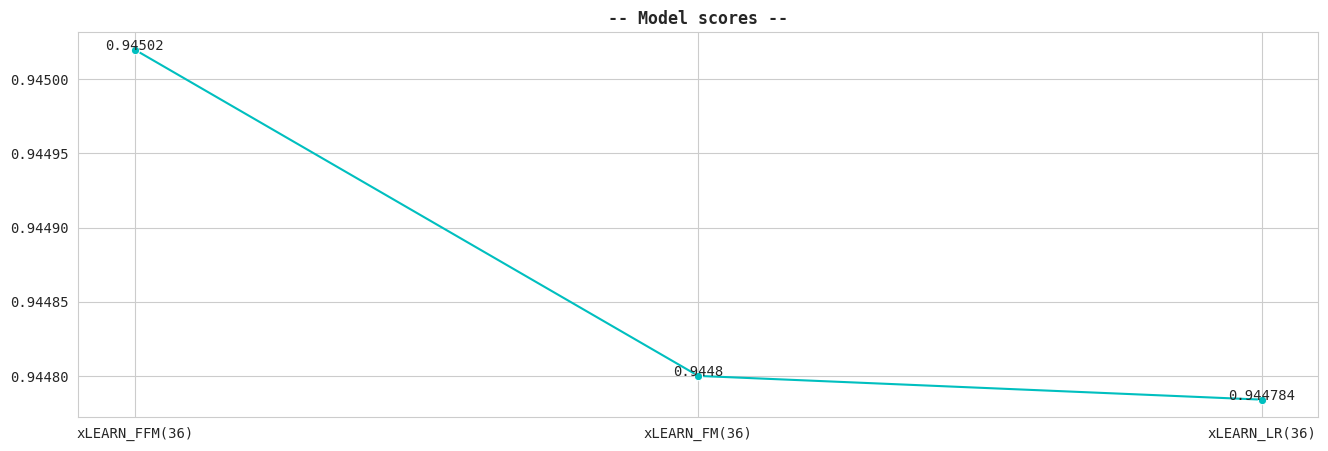

In [29]:
## -- Get Scores --
all_scores = {}

for k, v in all_predictions.items():
    for x, y in v.items():
        if x == "score":
            all_scores[k] = y

plt.figure(figsize=(16, 5))
ax = sns.lineplot(all_scores, marker='o')

# ax.fill_between(range(len(all_model_scores)), all_model_scores.values(), alpha=0.1)
ax.set_title("-- Model scores --", fontweight="semibold")
ax.tick_params('x', rotation=0)

for i, s in enumerate(all_scores.values()):
    ax.text(float(i), s+1e-8, s, ha="center", va="baseline")

# plt.tight_layout()
plt.show() 

xLEARN_FFM(36)_94502 saved!


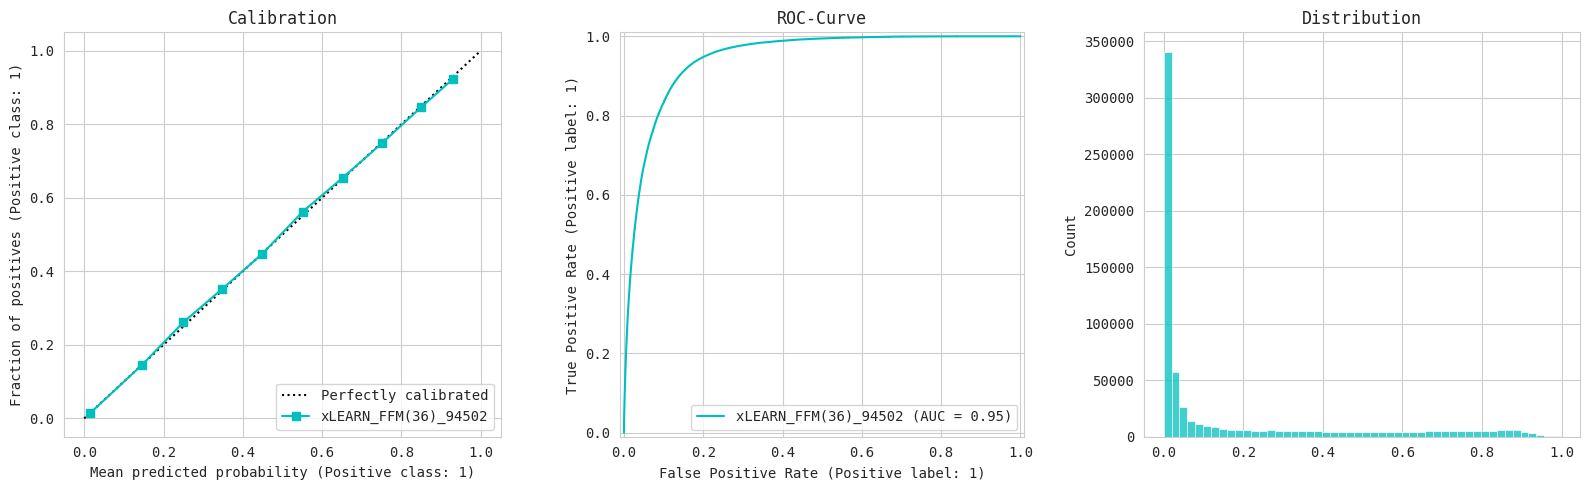


xLEARN_FM(36)_9448 saved!


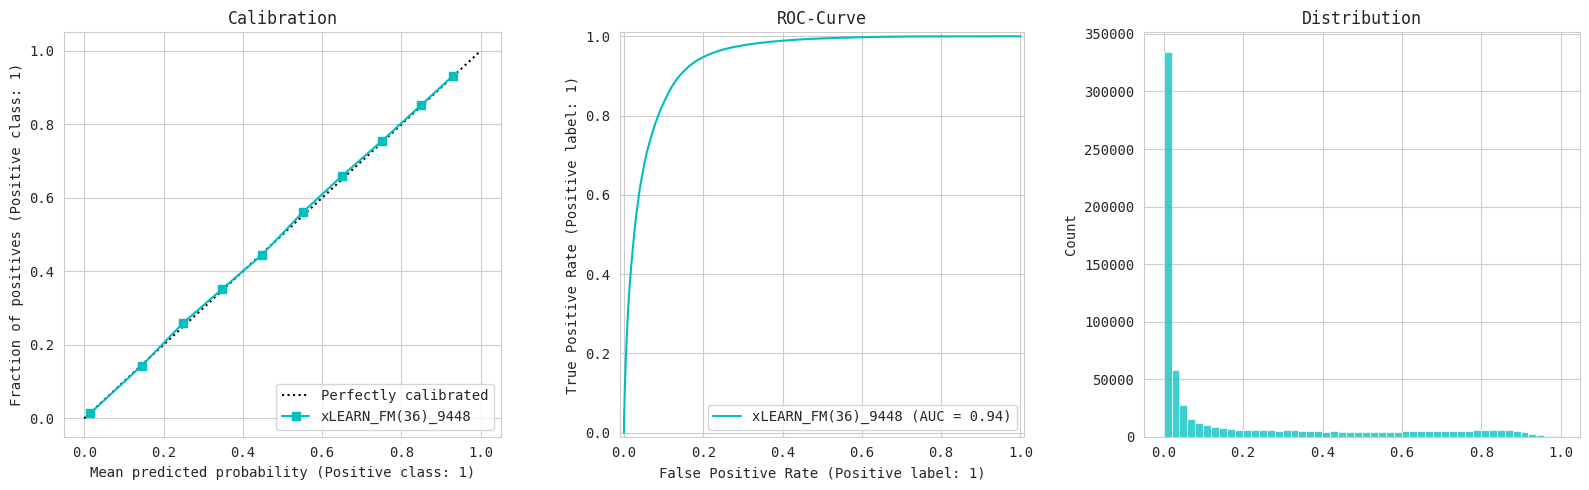


xLEARN_LR(36)_944784 saved!


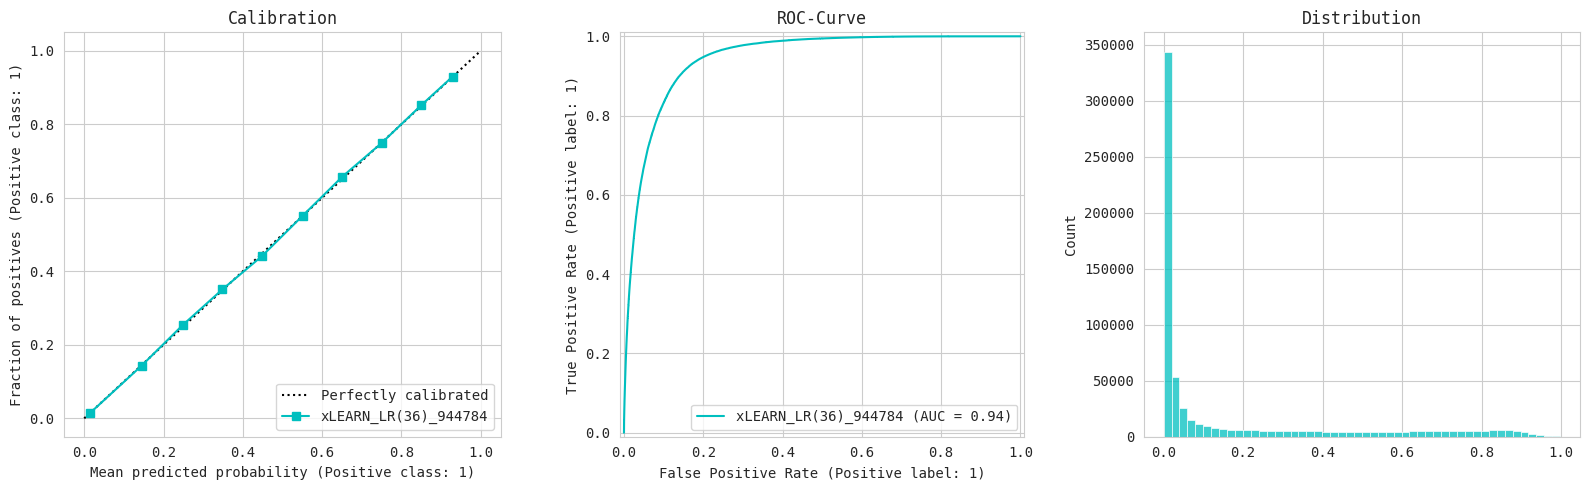

In [30]:
## -- Get oof predictions --
oof_predictions = []

for i, (k, v) in enumerate(all_predictions.items()):
    for key_, data_ in v.items():
        if key_ == "oof_preds":
            n = f"{k}_{str(all_scores[k]).split('.')[1]}"
            np.save(f"oof_{n}.npy", data_)
            print(f"{n} saved!")

            ## -- Plot distributions --
            _, axs = plt.subplots(1, 3, figsize=(16, 5)) 
            CalibrationDisplay.from_predictions(train_X[TARGET], data_, n_bins=10, name=n, ax=axs[0])
            axs[0].set_title("Calibration")

            RocCurveDisplay.from_predictions(train_X[TARGET], data_, name=n, ax=axs[1])
            axs[1].set_title("ROC-Curve")

            sns.histplot(data_, ax=axs[2], bins=50)
            axs[2].set_title("Distribution")
            
            plt.tight_layout()
            plt.show()

            print()

In [31]:
## -- Save test predictions/submissions --
model_results = {}

for i, (k, v) in enumerate(all_predictions.items()):
    for j, (x, y) in enumerate(v.items()):
        if x == "test_preds":
            ## -- Base submission file --
            n = f"{k}_{str(all_scores[k]).split('.')[1]}"
            np.save(f"test_{n}.npy", y)

            submission[TARGET] = y
            submission.to_csv(f"submit_{n}.csv", index=False)
            print(f"{n:>25s} saved! {y.shape}")

            model_results[n[:-7]] = y

print()
model_results = pd.DataFrame(model_results)
model_results

     xLEARN_FFM(36)_94502 saved! (286571,)
       xLEARN_FM(36)_9448 saved! (286571,)
     xLEARN_LR(36)_944784 saved! (286571,)



,xLEARN_FFM(36,xLEARN_FM(3,xLEARN_LR(36)
0,0.024498,0.022776,0.017767
1,0.016969,0.019681,0.017183
2,0.004068,0.002532,0.002081
3,0.002855,0.001696,0.001365
4,0.026742,0.027638,0.022953
...,...,...,...
286566,0.000466,0.000153,0.000096
286567,0.332621,0.364285,0.362895
286568,0.002662,0.001470,0.001038
286569,0.000708,0.000283,0.000188


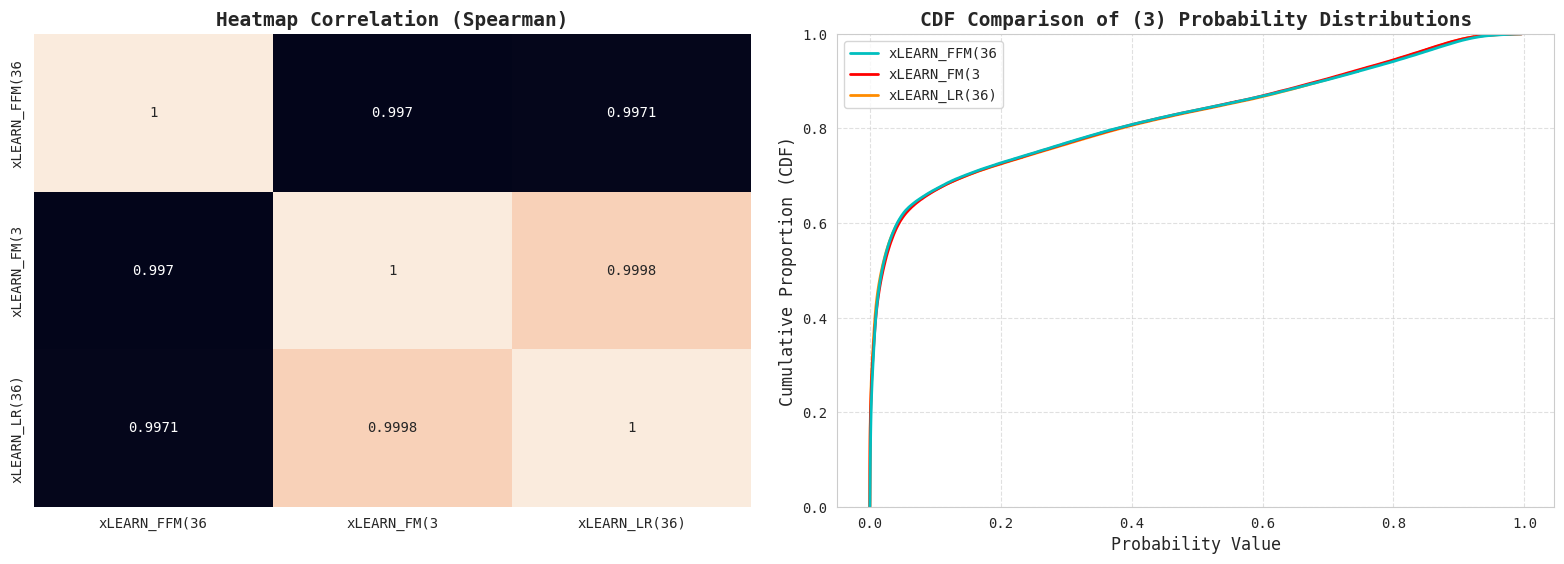

In [32]:
mdls = model_results.shape[1]

if mdls > 1:
    # display(model_results.corr("spearman"))
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    sns.heatmap(model_results.corr("spearman"), annot=True, fmt=".4g", cbar=False, ax=ax1)
    ax1.set_title('Heatmap Correlation (Spearman)', fontsize=14, fontweight='bold')
    
    sns.ecdfplot(data=model_results, linewidth=2, ax=ax2)
    ax2.set_title(f"CDF Comparison of ({mdls}) Probability Distributions", fontsize=14, fontweight='bold')
    ax2.set_xlabel('Probability Value', fontsize=12)
    ax2.set_ylabel('Cumulative Proportion (CDF)', fontsize=12)
    ax2.grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout(pad=2.0)
    plt.show()

In [33]:
# !rm -r /kaggle/working/